# Diffusion MRI: Diffusion Tensor Imaging (DTI)

This notebook demonstrates diffusion tensor estimation from multi-direction diffusion-weighted MRI data.

## Forward Model

The Stejskal-Tanner equation describes the signal attenuation due to water diffusion:

$$S(\mathbf{g}_i, b_i) = S_0 \cdot \exp\!\left(-b_i \cdot \mathbf{g}_i^\top \mathbf{D} \, \mathbf{g}_i\right)$$

where $\mathbf{D}$ is a 3×3 symmetric positive-definite diffusion tensor with 6 independent elements, $\mathbf{g}_i$ is the gradient direction, $b_i$ is the diffusion weighting, and $S_0$ is the baseline signal.

## Inverse Problem

Given noisy DWI measurements at multiple gradient directions, estimate the 6 tensor elements per voxel. From the eigendecomposition of $\mathbf{D}$, derive:
- **Fractional Anisotropy (FA)**: directional preference of diffusion (0 = isotropic, 1 = fully anisotropic)
- **Mean Diffusivity (MD)**: average diffusion rate

## Noise Model

Magnitude MRI data has Rician noise: $S_{\text{noisy}} = |S + \eta|$ where $\eta \sim \mathcal{CN}(0, \sigma^2)$.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

TASK_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, TASK_DIR)

%matplotlib inline

## 1. Load Data and Ground Truth

The synthetic dataset is a 128×128 modified Shepp-Logan phantom with tissue-specific diffusion tensor properties:
- **Bone/scalp**: low MD, low FA
- **White matter**: moderate MD, high FA (anisotropic along fiber direction)
- **Gray matter**: moderate MD, low FA (mostly isotropic)
- **CSF**: high MD, isotropic (FA ≈ 0)

The gradient table has 30 uniformly distributed directions (Fibonacci sphere) at b = 1000 s/mm² plus 1 b=0 volume. Rician noise with σ = 0.02 is added.

In [2]:
from src.preprocessing import load_dwi_data, load_ground_truth, load_metadata, preprocess_dwi

dwi_signal, bvals, bvecs = load_dwi_data(TASK_DIR)
fa_gt, md_gt, tensor_gt, tissue_mask = load_ground_truth(TASK_DIR)
meta = load_metadata(TASK_DIR)

print(f"DWI signal: {dwi_signal.shape} (batch, Ny, Nx, N_volumes)")
print(f"b-values: {np.unique(bvals)} s/mm²")
print(f"Gradient directions: {(bvals > 10).sum()}")
print(f"Noise sigma: {meta['noise_sigma']}")
print(f"Tissue pixels: {tissue_mask.sum()}")

DWI signal: (1, 128, 128, 31) (batch, Ny, Nx, N_volumes)
b-values: [   0. 1000.] s/mm²
Gradient directions: 30
Noise sigma: 0.02
Tissue pixels: 7186


## 2. Ground Truth FA and MD Maps

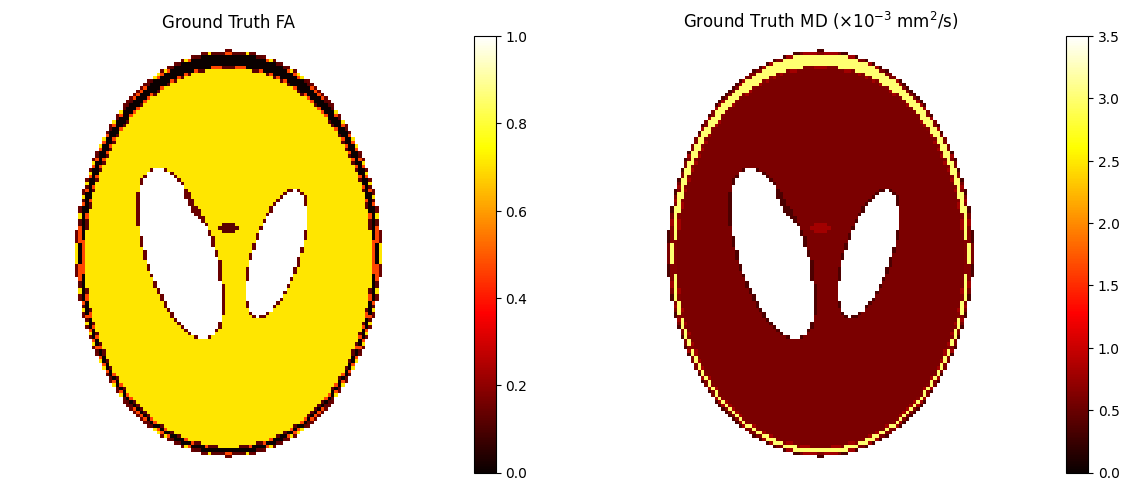

In [3]:
mask_2d = tissue_mask[0]
fa_gt_2d = np.where(mask_2d, fa_gt[0], np.nan)
md_gt_2d = np.where(mask_2d, md_gt[0] * 1e3, np.nan)  # in 10^-3 mm^2/s

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(fa_gt_2d, vmin=0, vmax=1, cmap='hot')
axes[0].set_title('Ground Truth FA')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(md_gt_2d, vmin=0, vmax=3.5, cmap='hot')
axes[1].set_title(r'Ground Truth MD ($\times 10^{-3}$ mm$^2$/s)')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

## 3. DWI Signal Examples

Visualize how the DWI signal varies across gradient directions at selected voxels. High-FA white matter voxels show strong direction-dependent attenuation, while isotropic CSF shows uniform decay.

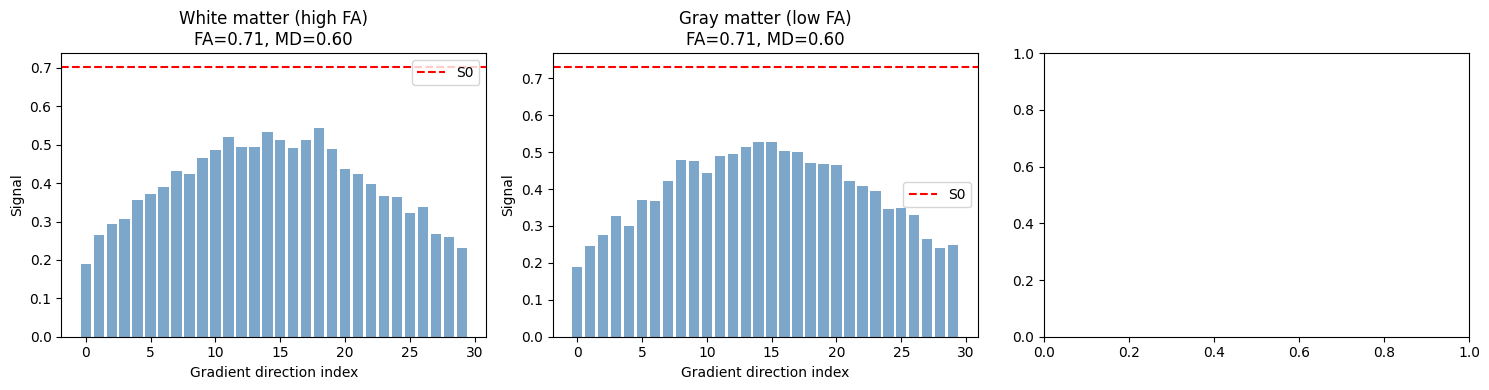

In [4]:
dwi_2d, S0_2d = preprocess_dwi(dwi_signal, bvals, bvecs)

# Pick representative voxels
cy, cx = 64, 64
voxels = {
    'White matter (high FA)': (45, 64),
    'Gray matter (low FA)': (64, 64),
    'CSF (isotropic)': (64, 50),
}

dwi_idx = np.where(bvals > 10)[0]  # DWI volumes only

fig, axes = plt.subplots(1, len(voxels), figsize=(5 * len(voxels), 4))
for i, (label, (vy, vx)) in enumerate(voxels.items()):
    if not mask_2d[vy, vx]:
        continue
    s = dwi_2d[vy, vx, dwi_idx]
    axes[i].bar(range(len(s)), s, color='steelblue', alpha=0.7)
    axes[i].axhline(S0_2d[vy, vx], color='r', ls='--', label='S0')
    axes[i].set_xlabel('Gradient direction index')
    axes[i].set_ylabel('Signal')
    axes[i].set_title(f'{label}\nFA={fa_gt[0, vy, vx]:.2f}, MD={md_gt[0, vy, vx]*1e3:.2f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

## 4. Precomputed DTI Results

Load precomputed OLS and WLS tensor fitting results from `evaluation/reference_outputs/`.

In [5]:
ref_dir = os.path.join(TASK_DIR, 'evaluation', 'reference_outputs')

ols_data = np.load(os.path.join(ref_dir, 'dti_ols.npz'))
wls_data = np.load(os.path.join(ref_dir, 'dti_wls.npz'))

fa_ols = ols_data['fa_map'][0]
md_ols = ols_data['md_map'][0]
fa_wls = wls_data['fa_map'][0]
md_wls = wls_data['md_map'][0]

print(f"OLS FA range: [{fa_ols[mask_2d].min():.4f}, {fa_ols[mask_2d].max():.4f}]")
print(f"WLS FA range: [{fa_wls[mask_2d].min():.4f}, {fa_wls[mask_2d].max():.4f}]")

OLS FA range: [0.0235, 0.8322]
WLS FA range: [0.0286, 0.8246]


## 5. FA and MD Comparison: OLS vs WLS

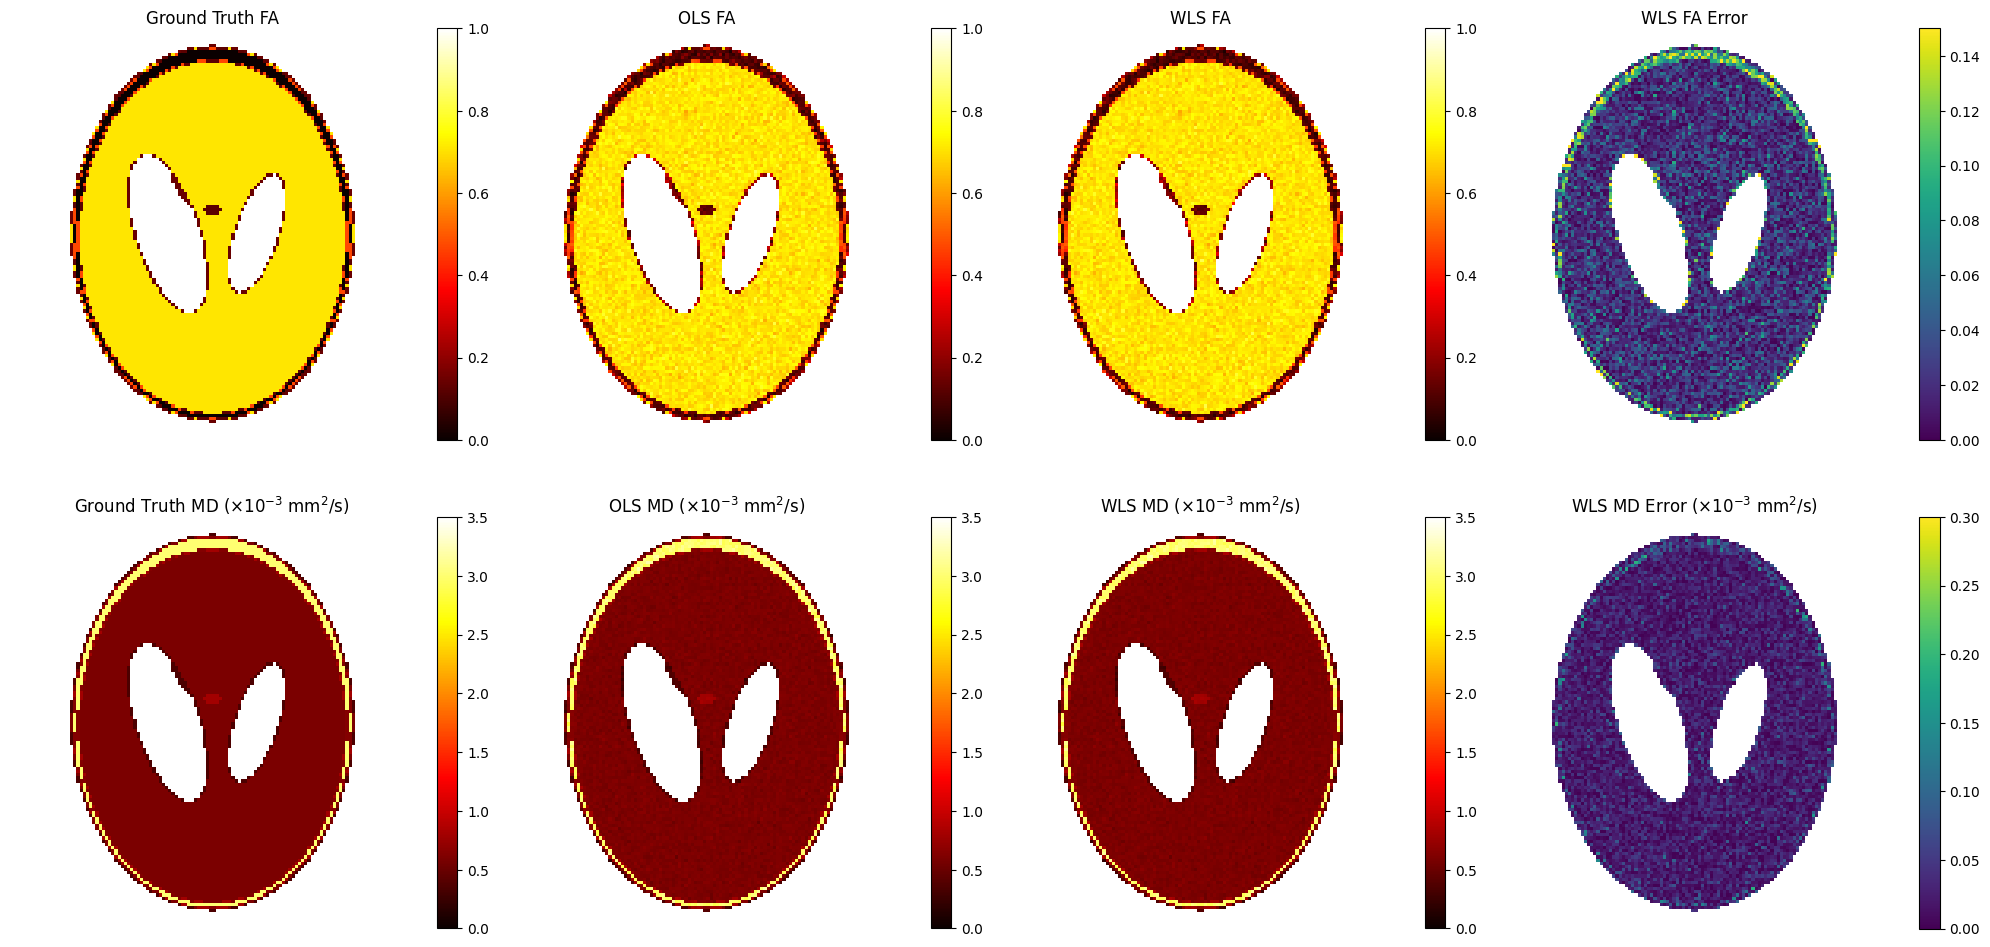

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

fa_gt_d = np.where(mask_2d, fa_gt[0], np.nan)
fa_ols_d = np.where(mask_2d, fa_ols, np.nan)
fa_wls_d = np.where(mask_2d, fa_wls, np.nan)

# FA row
for ax, data, title in zip(axes[0, :3],
    [fa_gt_d, fa_ols_d, fa_wls_d],
    ['Ground Truth FA', 'OLS FA', 'WLS FA']):
    im = ax.imshow(data, vmin=0, vmax=1, cmap='hot')
    ax.set_title(title)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

# FA error
fa_err_ols = np.where(mask_2d, np.abs(fa_ols - fa_gt[0]), np.nan)
fa_err_wls = np.where(mask_2d, np.abs(fa_wls - fa_gt[0]), np.nan)
im = axes[0, 3].imshow(fa_err_wls, vmin=0, vmax=0.15, cmap='viridis')
axes[0, 3].set_title('WLS FA Error')
axes[0, 3].axis('off')
plt.colorbar(im, ax=axes[0, 3], fraction=0.046)

# MD row
md_gt_d = np.where(mask_2d, md_gt[0] * 1e3, np.nan)
md_ols_d = np.where(mask_2d, md_ols * 1e3, np.nan)
md_wls_d = np.where(mask_2d, md_wls * 1e3, np.nan)

for ax, data, title in zip(axes[1, :3],
    [md_gt_d, md_ols_d, md_wls_d],
    ['Ground Truth MD', 'OLS MD', 'WLS MD']):
    im = ax.imshow(data, vmin=0, vmax=3.5, cmap='hot')
    ax.set_title(title + r' ($\times 10^{-3}$ mm$^2$/s)')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

md_err_wls = np.where(mask_2d, np.abs(md_wls - md_gt[0]) * 1e3, np.nan)
im = axes[1, 3].imshow(md_err_wls, vmin=0, vmax=0.3, cmap='viridis')
axes[1, 3].set_title(r'WLS MD Error ($\times 10^{-3}$ mm$^2$/s)')
axes[1, 3].axis('off')
plt.colorbar(im, ax=axes[1, 3], fraction=0.046)

plt.tight_layout()
plt.show()

## 6. Directional Color FA Map

Color FA encodes the primary diffusion direction as RGB (R = left-right, G = anterior-posterior, B = superior-inferior), modulated by FA brightness.

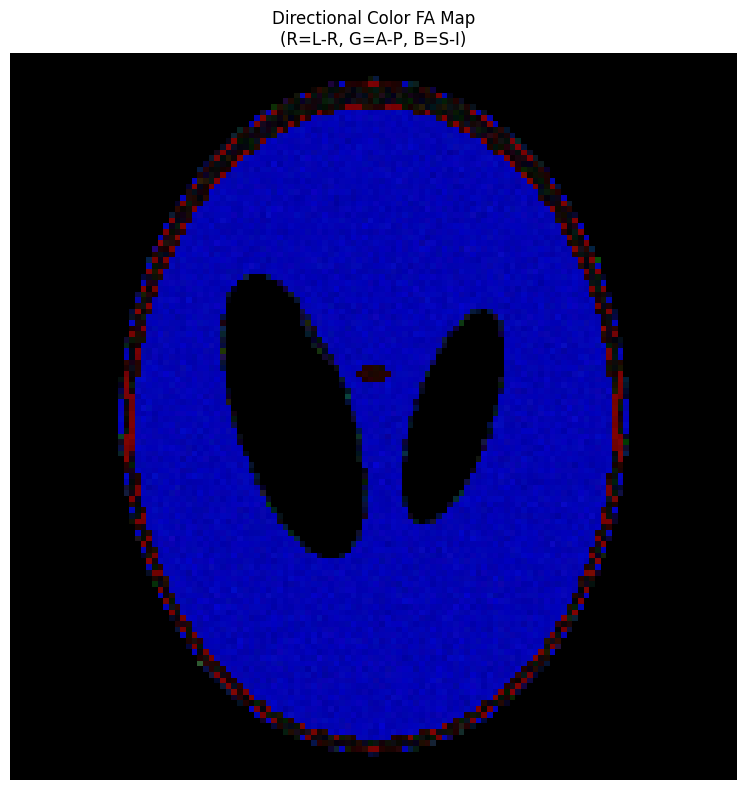

In [7]:
from src.solvers import tensor_eig_decomposition

_, evecs_wls, _, _ = tensor_eig_decomposition(
    wls_data['tensor_elements'][0], mask=mask_2d
)

# Build color FA
v1 = evecs_wls[..., :, 0]  # primary eigenvector
v1_abs = np.abs(v1)
v1_norm = np.linalg.norm(v1_abs, axis=-1, keepdims=True)
v1_norm = np.maximum(v1_norm, 1e-10)
v1_abs = v1_abs / v1_norm
color_fa = v1_abs * fa_wls[..., np.newaxis]
color_fa = np.where(mask_2d[..., np.newaxis], color_fa, 0.0)
color_fa = np.clip(color_fa, 0, 1)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(color_fa)
ax.set_title('Directional Color FA Map\n(R=L-R, G=A-P, B=S-I)')
ax.axis('off')
plt.tight_layout()
plt.show()

## 7. Quantitative Metrics

In [8]:
import json

with open(os.path.join(TASK_DIR, 'evaluation', 'metrics.json')) as f:
    metrics = json.load(f)

print("Method               | FA NCC  | FA NRMSE | MD NCC  | MD NRMSE")
print("-" * 68)
for entry in metrics['baseline']:
    print(f"{entry['method']:20s} | {entry['ncc_vs_ref']:.4f}  | {entry['nrmse_vs_ref']:.4f}   | {entry['ncc_md']:.4f}  | {entry['nrmse_md']:.4f}")
print(f"\nBoundaries: NCC >= {metrics['ncc_boundary']:.4f}, NRMSE <= {metrics['nrmse_boundary']:.4f}")

Method               | FA NCC  | FA NRMSE | MD NCC  | MD NRMSE
--------------------------------------------------------------------
OLS tensor fit       | 0.9978  | 0.0613   | 0.9993  | 0.0135
WLS tensor fit       | 0.9980  | 0.0585   | 0.9993  | 0.0134

Boundaries: NCC >= 0.8982, NRMSE <= 0.0643


## 8. Optional: Run Full Pipeline from Scratch

Uncomment the cell below to reproduce the results from scratch (takes ~30 seconds).

In [9]:
# from src.preprocessing import preprocess_dwi
# from src.solvers import fit_dti_ols, fit_dti_wls, tensor_eig_decomposition
# from src.visualization import compute_ncc, compute_nrmse
#
# dwi_2d, S0_2d = preprocess_dwi(dwi_signal, bvals, bvecs)
# mask_2d = tissue_mask[0]
#
# # OLS fit
# tensor_ols, S0_ols = fit_dti_ols(dwi_2d, bvals, bvecs, mask=mask_2d)
# evals_ols, evecs_ols, fa_ols, md_ols = tensor_eig_decomposition(tensor_ols, mask=mask_2d)
#
# # WLS fit
# tensor_wls, S0_wls = fit_dti_wls(dwi_2d, bvals, bvecs, mask=mask_2d)
# evals_wls, evecs_wls, fa_wls, md_wls = tensor_eig_decomposition(tensor_wls, mask=mask_2d)
#
# # Evaluate
# fa_gt_2d = fa_gt[0]
# print(f"OLS FA NCC: {compute_ncc(fa_ols, fa_gt_2d, mask=mask_2d):.4f}")
# print(f"WLS FA NCC: {compute_ncc(fa_wls, fa_gt_2d, mask=mask_2d):.4f}")

## Conclusion

**Key observations:**

1. **Both OLS and WLS achieve high accuracy** on this synthetic dataset (FA NCC > 0.99), demonstrating that 30 gradient directions at b=1000 s/mm² provide sufficient conditioning for tensor estimation.

2. **WLS slightly outperforms OLS** in FA estimation (lower NRMSE), consistent with theory — the weighting corrects for heteroscedastic noise in the log domain.

3. **MD estimation is more robust than FA** — MD averages over all eigenvalues and is less sensitive to noise, while FA depends on eigenvalue differences which amplify noise.

4. **Color FA maps** reveal the assigned fiber orientations: horizontal white matter fibers (red), vertical deep gray/white matter (green), with isotropic regions (CSF, gray matter) appearing dark.

**Challenges for real data:**
- Lower SNR requires more gradient directions and potentially higher-order fitting
- Rician noise bias at low SNR systematically overestimates FA
- Crossing fibers within a voxel violate the single-tensor model (requires HARDI/CSD)
- Subject motion between DWI volumes requires registration